# Regression
Regression is used to perform trend analysis on a given dataset.
We need to perform a linear fit, so our data will be approximated to:
\begin{equation}
    y = b_0 + b_1\cdot x
\end{equation}
Linear regression consists on estimating $b_0$ and $b_1$. A metric used to evaluate the goodness of the model is $R^2$. It is defined as the following:
\begin{equation}
    R^2 = \frac{SSR}{SST} = \frac{SST - SSE}{SST}
\end{equation}

\begin{equation}
    R^2_{adj} = 1 - \frac{(1-R^2)(n-1)}{n-k-1}
\end{equation}

$SSR$ is the sum of square of residual. It indicates how much data fitted in the model differs from the mean value of original data (we take always the sum of squares to remove negative values).
\begin{equation}
    SSR = \sum_{i=1}^n (y_{fit} - \overline{y})^2
\end{equation}

$SSE$ is the sum of square of error. It indicates how much data fitted in the model differs from theoriginal data (we take always the sum of squares to remove negative values).
\begin{equation}
    SSE = \sum_{i=1}^n (y - y_{fit})^2
\end{equation}

$SST$ is the total sum of squares. It is obtained by sum of $SSE$ and $SSR$.
\begin{equation}
    SST = SSR + SSE
\end{equation}


In [3]:
import pandas as pd
import pymannkendall as mk

from scipy import stats
from collections import namedtuple

fname = "homework_regression.xls"

sheets = {
    "EXP1": {
        "y": ["nmail", "byte rec", "byte sent"],
        "x": lambda df: range(df["observation"].shape[0]),
        "xlabel": "Observations",
    },
    "EXP2": {
        "y": ["nmail", "byte rec", "byte sent"],
        "x": lambda df: df["observation"],
        "xlabel": "Observations",
    },
    "os1": {
        "y": ["LIN1_VmSize", "LIN1_VmData", "LIN1_RSS", "LIN1_byte_letti_I_O", "LIN1_byte_letti_I_O1"],
        "x": lambda df: df["TIME"],
        "xlabel": "Time",
    },
    "os2": {
        "y": ["LIN2_VmSize", "LIN2_VmData", "LIN2_RSS", "LIN2_byte_letti__sec", "LIN2_byte_scritti__sec"],
        "x": lambda df: df["TIME"],
        "xlabel": "Time",
    },
    "os3": {
        "y": ["LIN4_VmSize", "LIN4_VmData", "LIN4RSS", "LIN4_byte_letti__sec", "LIN4_byte_scritti__sec"],
        "x": lambda df: df["TIME"],
        "xlabel": "Time",
    },
    "VMres1":  {
        "y": ["Allocated Heap"],
        "x": lambda df: df["T(s)"],
        "xlabel": "T(s)",
    },
    "VMres2":  {
        "y": ["allocated heap"],
        "x": lambda df: df["T (s)"],
        "xlabel": "T(s)",
    },
    "VMres3":  {
        "y": ["allocated heap"],
        "x": lambda df: df["T(s)"],
        "xlabel": "T(s)",
    },
}

results = {}

RegressionResult = namedtuple("RegressionResult", ("model", "fitted_data", "rsquared", "rsquared_adj"))

def rsquared(predicted_data: pd.Series, observed_data: pd.Series) -> float:
    t = observed_data - predicted_data
    sse = t.pow(2).sum()

    t = predicted_data - observed_data.mean()
    ssr = t.pow(2).sum()

    sst = ssr + sse
    return ssr / sst
                              
for sheet in sheets:
    df = pd.read_excel(fname, sheet_name=sheet)
    params = sheets[sheet]
    
    ys = params["y"]
    x =  params["x"](df)
    x = pd.Series(x)
    
    results[sheet] = {}

    for ylabel in ys:
        ths = stats.theilslopes(df[ylabel], x)
        ths_fitted = pd.Series(ths.slope*x + ths.intercept)
        ths_rsquared = rsquared(ths_fitted, df[ylabel])
        
        lsq = stats.linregress(x, df[ylabel])
        lsq_fitted = pd.Series(lsq.slope*x + lsq.intercept)
        lsq_rsquared = rsquared(lsq_fitted, df[ylabel])

        rsquared_adj_lsq = 1 - (((1-lsq_rsquared)*(len(x) - 1))/(len(x) - 2))
        rsquared_adj_ths = 1 - (((1-ths_rsquared)*(len(x) - 1))/(len(x) - 2))
        mann_kendall = mk.original_test(df[ylabel])
        
        results[sheet][ylabel] = {
            "models": (
                RegressionResult(ths, ths_fitted, ths_rsquared, rsquared_adj_ths), 
                RegressionResult(lsq, lsq_fitted, lsq_rsquared, rsquared_adj_lsq), 
                mann_kendall), 
            "data": df[ylabel],
            "x": x,
            "xlabel": params["xlabel"],
        }
        print(f"{sheet}:", "var:", ylabel)
        print(f"R^2 (check) = {lsq.rvalue**2}", f"R^2 (lsq) = {lsq_rsquared}", f"R^2 (ths) = {ths_rsquared}", sep="; ")
        print(ths, lsq, mann_kendall, sep="\n", end="\n\n")

EXP1: var: nmail
R^2 (check) = 8.683691326244247e-07; R^2 (lsq) = 8.683691326244276e-07; R^2 (ths) = 0.0008514762199870418
TheilslopesResult(slope=0.0, intercept=297.0, low_slope=0.0, high_slope=0.0)
LinregressResult(slope=-5.451680580917116e-06, intercept=296.5805818904666, rvalue=-0.0009318632585440981, pvalue=0.9295611751263875, stderr=6.167098698999543e-05, intercept_stderr=0.3204607497753812)
Mann_Kendall_Test(trend='no trend', h=False, p=0.7163841564535962, z=-0.3632954974204759, Tau=-0.0025525805774667012, s=-103391.0, var_s=80991051964.33333, slope=0.0, intercept=297.0)

EXP1: var: byte rec
R^2 (check) = 0.00016378157932849446; R^2 (lsq) = 0.00016378157932849443; R^2 (ths) = 0.0009024330243696582
TheilslopesResult(slope=-4.563511753923477, intercept=10410796.802892655, low_slope=-11.511506276150628, high_slope=2.4138321995464853)
LinregressResult(slope=-4.485068517611781, intercept=10435118.099296922, rvalue=-0.012797717739053884, pvalue=0.22472991390472952, stderr=3.6940592864

## Plot

saved build/exp1.1.pdf
saved build/exp1.2.pdf
saved build/exp1.3.pdf
saved build/exp2.1.pdf
saved build/exp2.2.pdf
saved build/exp2.3.pdf
saved build/os1.1.pdf
saved build/os1.2.pdf
saved build/os1.3.pdf
saved build/os1.4.pdf
saved build/os1.5.pdf
saved build/os2.1.pdf
saved build/os2.2.pdf
saved build/os2.3.pdf
saved build/os2.4.pdf
saved build/os2.5.pdf
saved build/os3.1.pdf
saved build/os3.2.pdf
saved build/os3.3.pdf
saved build/os3.4.pdf
saved build/os3.5.pdf
saved build/vmres1.1.pdf
saved build/vmres2.1.pdf
saved build/vmres3.1.pdf


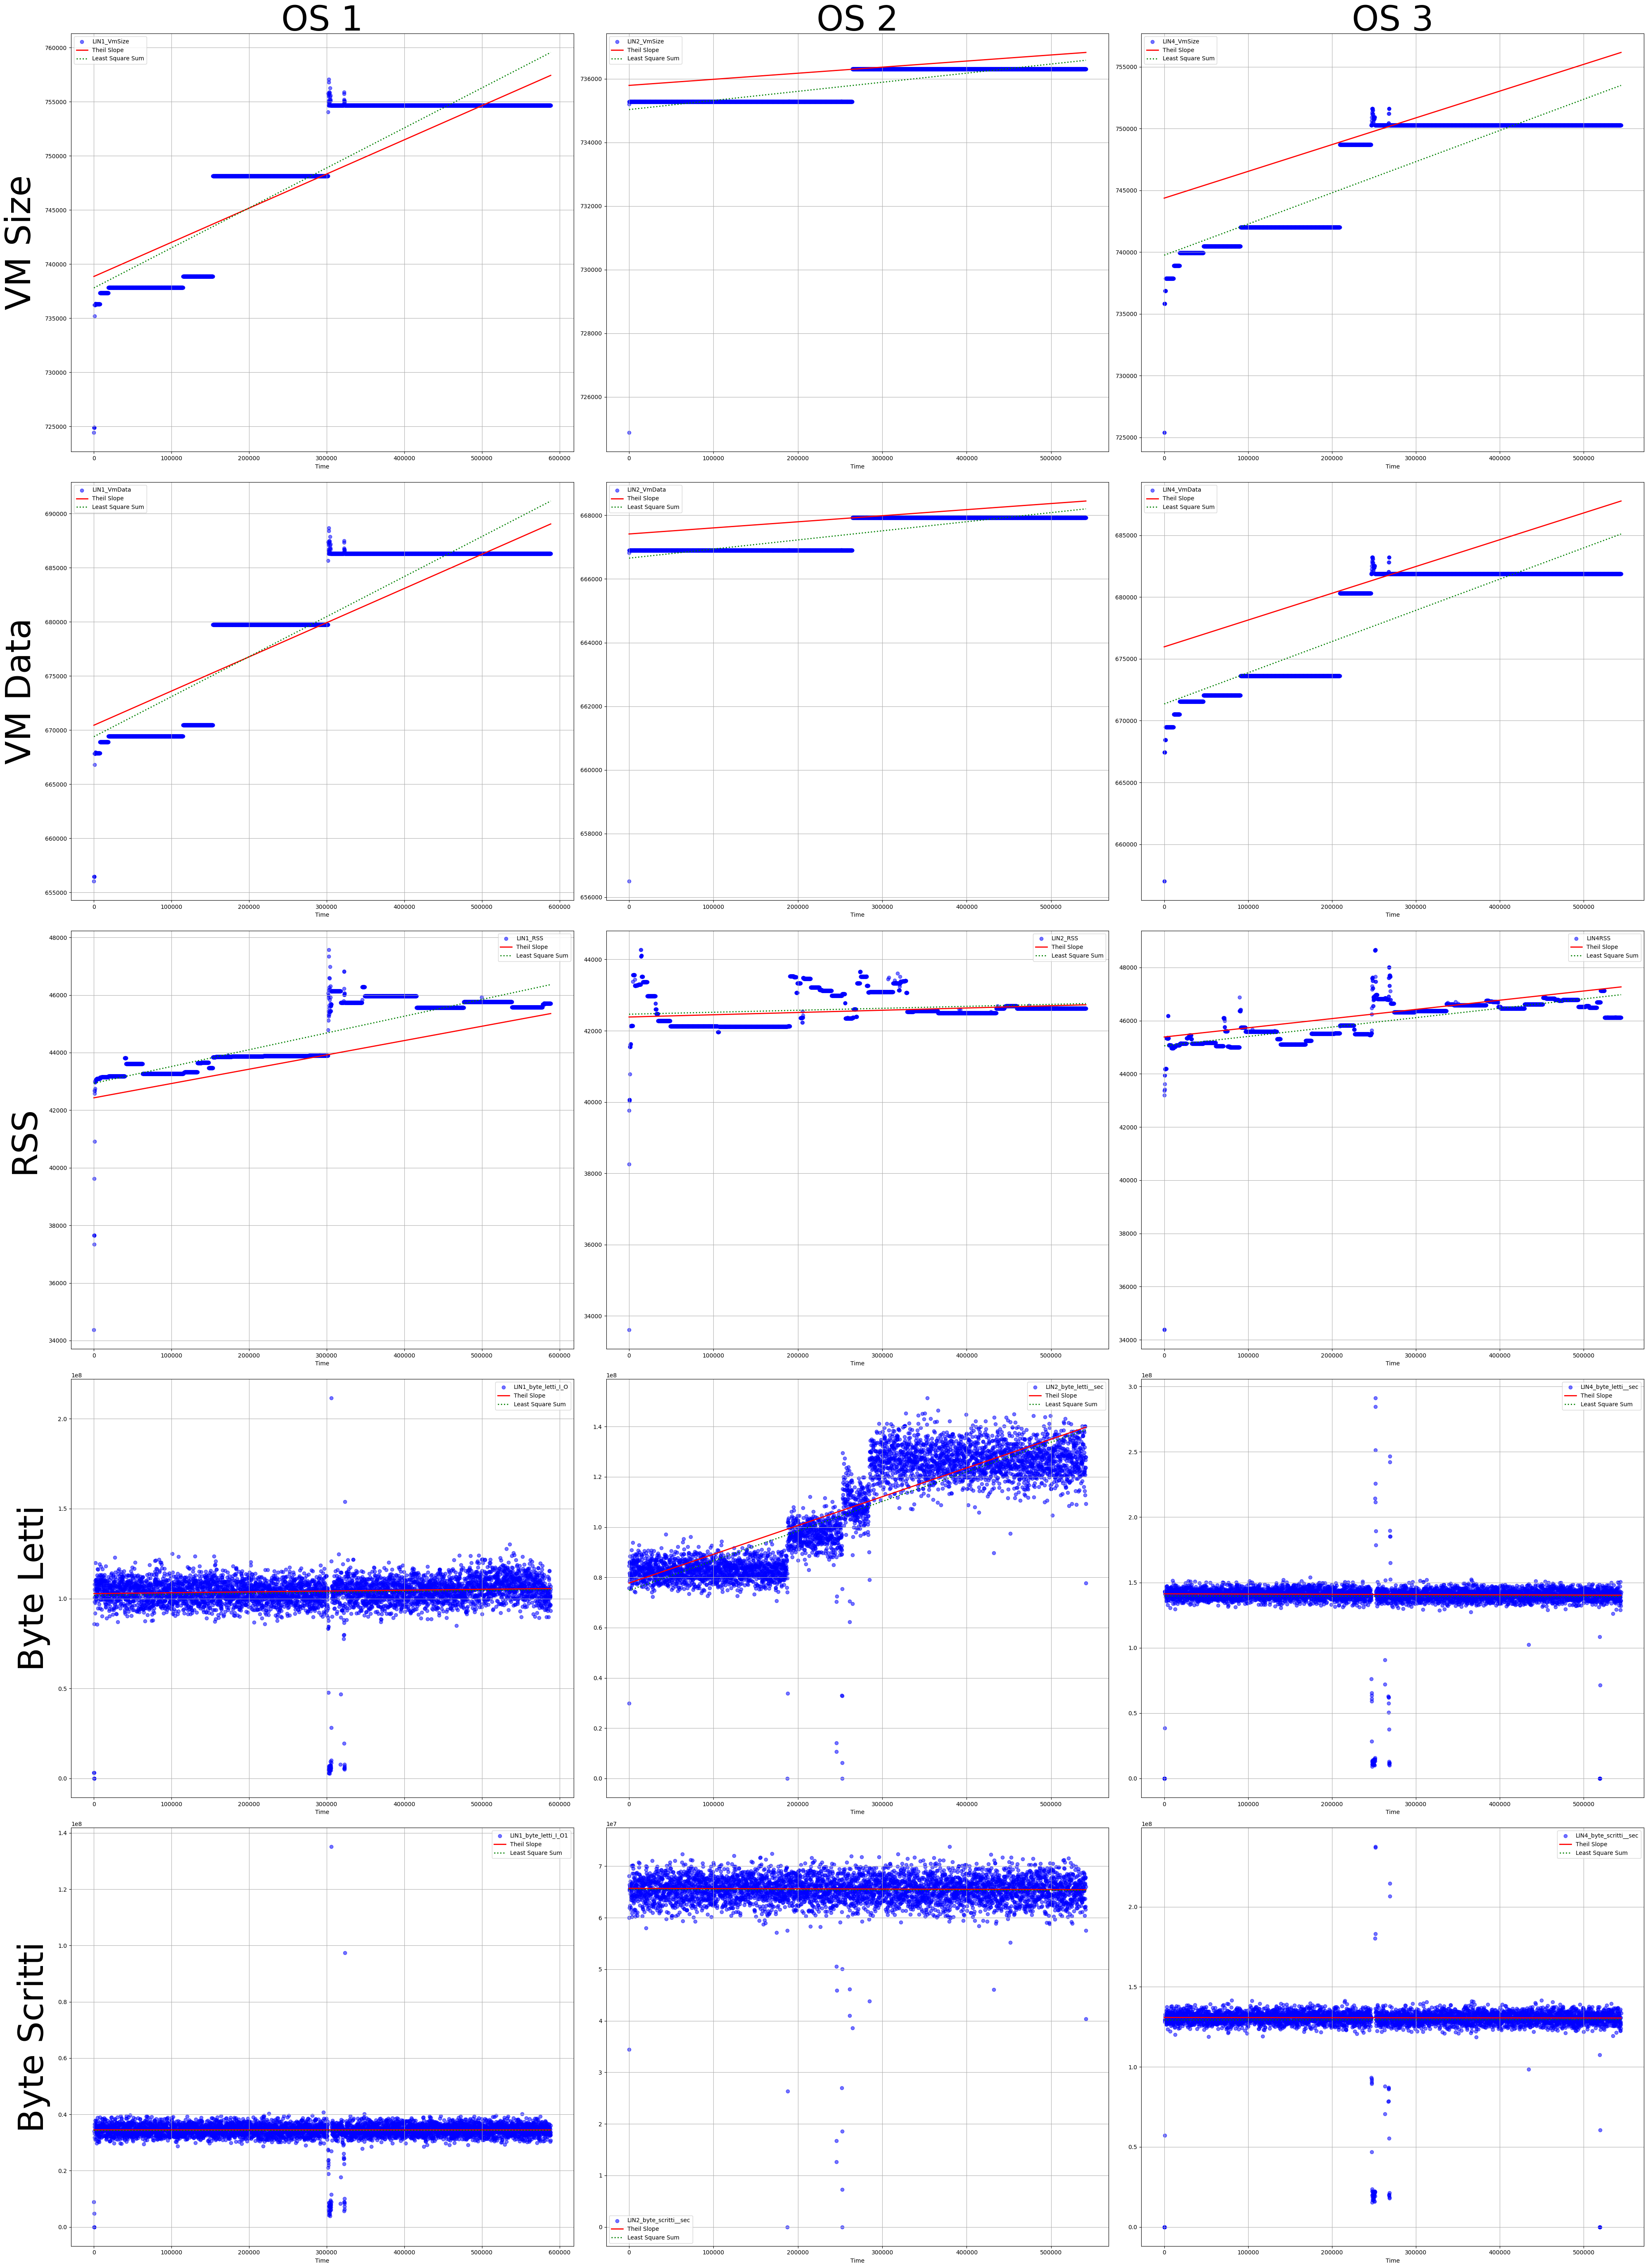

In [3]:
import os
import matplotlib.pyplot as plt

from pathlib import Path

def plot(ax: plt.Axes, title: str, xlabel: str, ylabel: str, x, y, legend: str, ths, lsq) -> None:
    th_slope, th_intercept, th_low_slope, th_high_slope = ths
    ls_slope, ls_intercept, r_value, p_value, stderr = lsq
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.scatter(x, y, label=legend, color="b", alpha=0.55)
    ax.plot(x, th_slope * x + th_intercept, color="r", label="Theil Slope", linewidth=2)
    ax.plot(x, ls_slope * x + ls_intercept, color="g", label="Least Square Sum", linewidth=2, linestyle = "dotted")
    ax.legend()
    ax.grid(True)
    return

def plot_all_quick() -> None:
    for sheet_name, result in results.items():
        n = len(result)
        fig, axs = plt.subplots(n, figsize=(7 * n, 6 * n))
        fig.suptitle(sheet_name)
        fig.tight_layout(h_pad=7, w_pad=5)
        fig.subplots_adjust(top=0.9)
        for (i, variable) in enumerate(result):
            ths, lsq, x, y = result[variable]["models"][0][0], result[variable]["models"][1][0], result[variable]["x"], result[variable]["data"]
            ax = axs if n == 1 else axs[i]
            plot(ax, f"{sheet_name} - {variable}", result[variable]["xlabel"], variable, x, y, variable, ths, lsq)

def plot_single_pdf(directory: str) -> None:
    for sheet_name, result in results.items():
        for (i, variable) in enumerate(result):
            ths, lsq, x, y = result[variable]["models"][0][0], result[variable]["models"][1][0], result[variable]["x"], result[variable]["data"]
            th_slope, th_intercept, th_low_slope, th_high_slope = ths
            ls_slope, ls_intercept, r_value, p_value, stderr = lsq
            fig, ax = plt.subplots()
            plot(ax, f"{sheet_name} - {variable}", result[variable]["xlabel"], variable, x, y, variable, ths, lsq)
            p = os.path.join(directory, f"{sheet_name.lower()}.{i+1}.pdf")
            fig.savefig(p)
            plt.close()
            print("saved", p)
            
def plot_os_comparison(p: str) -> None:

    cols = ["OS 1", "OS 2", "OS 3"]
    rows = ["VM Size", "VM Data", "RSS", "Byte Letti", "Byte Scritti"]
    
    fig, axs = plt.subplots(5,3, figsize=(40, 55))
    
    for (i, label) in enumerate(["os1", "os2", "os3"]):
        os = results[label]
        for (j, variable) in enumerate(sheets[label]["y"]):
            models, x, xlabel, y = os[variable]["models"], os[variable]["x"], os[variable]["xlabel"], os[variable]["data"]
            plot(axs[j][i], "", xlabel, "", x, y, variable, models[0][0], models[1][0])
    
    pad = 5 # in points
    
    for ax, col in zip(axs[0], cols):
        ax.annotate(col, xy=(0.5, 1), xytext=(0, pad),
                    xycoords='axes fraction', textcoords='offset points',
                    size=60, ha='center', va='baseline')
    
    for ax, row in zip(axs[:,0], rows):
        ax.annotate(row, xy=(0, 0.7), xytext=(-ax.yaxis.labelpad - pad, 0),
                    xycoords=ax.yaxis.label, textcoords='offset points',
                    size=60, ha='right', va='center', rotation=90)
    fig.tight_layout()
    fig.savefig(p)

odir = "build"
Path(odir).mkdir(parents=True, exist_ok=True)

plot_single_pdf(odir)
plot_os_comparison(os.path.join(odir, "comp.pdf"))

In [10]:
import numpy as np

fname = "summary.csv"
fieldnames = ",".join(("sheet","variable", "mk_test", "mk_pvalue", "ths_slope", "ths_intercept", "ths_rsquare", "ths_rsquare_adj", "lsq_slope", "lsq_intercept", "lsq_rsquare", "lsq_adj", "rsquare_check"))

fmt = np.format_float_positional

with open(fname, "w") as f:
    f.write(fieldnames)
    f.write("\n")

    for sheet in results:
        vars = results[sheet]
        for var in vars:
            stats = vars[var]
            ths, ths_rsquare, ths_rsquare_adj, lsq, lsq_rsquare, lsq_rsquare_adj = stats["models"][0][0], stats["models"][0][2], stats["models"][0][3], stats["models"][1][0], stats["models"][1][2], stats["models"][1][3]
            mk = stats["models"][2]
            data = [fmt(x, precision=4) for x in (ths.slope, ths.intercept, ths_rsquare, ths_rsquare_adj,  lsq.slope, lsq.intercept, lsq_rsquare,lsq_rsquare_adj, lsq.rvalue**2)]
            f.write(",".join((sheet, var, mk.trend, fmt(mk.p, precision=4), *data)))
            f.write("\n")



In [9]:
results["os2"]["LIN2_VmData"]["models"]

(RegressionResult(model=TheilslopesResult(slope=0.0019128745423298214, intercept=667414.3761488455, low_slope=0.0, high_slope=0.002085369827305311), fitted_data=0       667414.376149
 1       667414.605694
 2       667414.835239
 3       667415.064784
 4       667415.294329
             ...      
 4506    668448.705671
 4507    668448.935216
 4508    668449.164761
 4509    668449.394306
 4510    668449.623851
 Name: TIME, Length: 4511, dtype: float64, rsquared=0.4850360353490232, rsquared_adj=0.4849218273284752),
 RegressionResult(model=LinregressResult(slope=0.0028618142132134108, intercept=666654.9621716654, rvalue=0.8326572900789445, pvalue=0.0, stderr=2.834516948156927e-05, intercept_stderr=8.857278313027994), fitted_data=0       666654.962172
 1       666655.305589
 2       666655.649007
 3       666655.992425
 4       666656.335842
             ...      
 4506    668202.402353
 4507    668202.745771
 4508    668203.089188
 4509    668203.432606
 4510    668203.776024
 Name: TIME,